# Примеры обучения моделей в Scikit-Learn

In [1]:
import sklearn
print('Версия sklearn: ',sklearn.__version__)

from sklearn import set_config
set_config(print_changed_only=False)

Версия sklearn:  1.8.0


### Логистическая регрессия

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
data = pd.read_csv('heart.csv')
Y = data['target']
X = data.drop('target', axis = 1)

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [6]:
model = LogisticRegression()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

D:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [8]:
accuracy_score(Y_test, Y_pred)

0.8852459016393442

In [9]:
confusion_matrix(Y_test, Y_pred)

array([[25,  4],
       [ 3, 29]])

In [10]:
tn,fp,fn,tp = confusion_matrix(Y_test, Y_pred).ravel()
(tn,fp,fn,tp)

(np.int64(25), np.int64(4), np.int64(3), np.int64(29))

In [11]:
matrix = classification_report(Y_test, Y_pred)
print(matrix)

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [12]:
new_Y_pred = np.array([1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1])

In [13]:
new_Y_test = np.array([1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])

In [14]:
tn,fp,fn,tp = confusion_matrix(new_Y_test, new_Y_pred).ravel()
(tn,fp,fn,tp)

(np.int64(10), np.int64(0), np.int64(5), np.int64(15))

In [15]:
print(confusion_matrix(new_Y_test, new_Y_pred))

[[10  0]
 [ 5 15]]


In [16]:
matrix = classification_report(new_Y_test, new_Y_pred)
print(matrix)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        10
           1       1.00      0.75      0.86        20

    accuracy                           0.83        30
   macro avg       0.83      0.88      0.83        30
weighted avg       0.89      0.83      0.84        30



### Метод решающих деревьев

Метод решающих деревьев
реализован классами `DecisionTreeRegressor` и `DecisionTreeClassifier` модуля `sklearn.tree`. Полную информацию об этих классах можно найти в документации по ссылке:

https://scikit-learn.org/stable/api/sklearn.tree.html

In [1]:
import sklearn
print('Версия sklearn: ',sklearn.__version__)

from sklearn import set_config
set_config(print_changed_only=False)

Версия sklearn:  1.8.0


Продемонстрируем применение метода решающих деревьев для решения задач классификации.

#### Пример 1

Рассмотрим работу метода решающих деревьев на примере датасета на примере задачи классификации ирисов. Подгрузим данные.

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

iris = load_iris()

Y = iris.target
X = iris.data[:,2:]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                    test_size = 0.2, 
                                                    random_state=137, 
                                                    stratify = Y)

Обучим модель.

In [39]:
model = DecisionTreeClassifier(random_state=137)
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",137
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

Проверим качество обученной модели на тестовых данных.

In [40]:
Y_pred = model.predict(X_test)

print("Точность предсказания (accuracy) равна  ", accuracy_score(Y_test,Y_pred)*100, "%")

Точность предсказания (accuracy) равна   93.33333333333333 %


In [41]:
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Можно выявить важность признаков. Тут видно, что один из признаков не важен.

In [42]:
model.feature_importances_

array([0.44352619, 0.55647381])

Можно также получить визуализацию дерева с отображением выбранных приназков, по которым проходит разбиение датасета на каждом шаге. Для этого можно использовать метод `plot_tree()` модуля `sklearn.tree`.

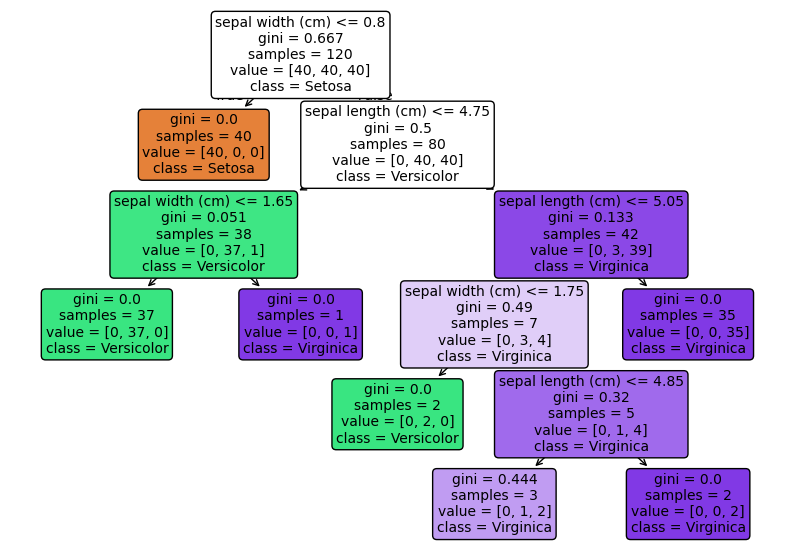

In [43]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(10, 7))

plot_tree(model, 
          filled=True, 
          rounded=True,
          class_names=['Setosa', 
                       'Versicolor',
                       'Virginica'],
          feature_names=iris.feature_names) 

plt.show()

In [44]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_decision_surface(model, X_train, X_test, Y_train, Y_test):

    # обучение переданной модели
    model.fit(X_train, Y_train)

    plt.figure(figsize=(12, 4))
    ax = plt.subplot(1, 2, 1)
    # решающая функция на обучающей выборке
    disp = DecisionBoundaryDisplay.from_estimator(model, X_train, 
                                                  response_method="predict",
                                                  ax = ax,
                                                  alpha=0.5)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, edgecolor="k")
    plt.title('Train data, accuracy={:.2f}'.format(accuracy_score(Y_train, model.predict(X_train))))
    
    # решающая функция на тестовой выборке
    ax = plt.subplot(1, 2, 2)
    # решающая функция на обучающей выборке
    disp = DecisionBoundaryDisplay.from_estimator(model, X_train, 
                                                  response_method="predict",
                                                  ax = ax,
                                                  alpha=0.5)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolor="k")
    plt.title('Test data, accuracy={:.2f}'.format(accuracy_score(Y_test, model.predict(X_test))))

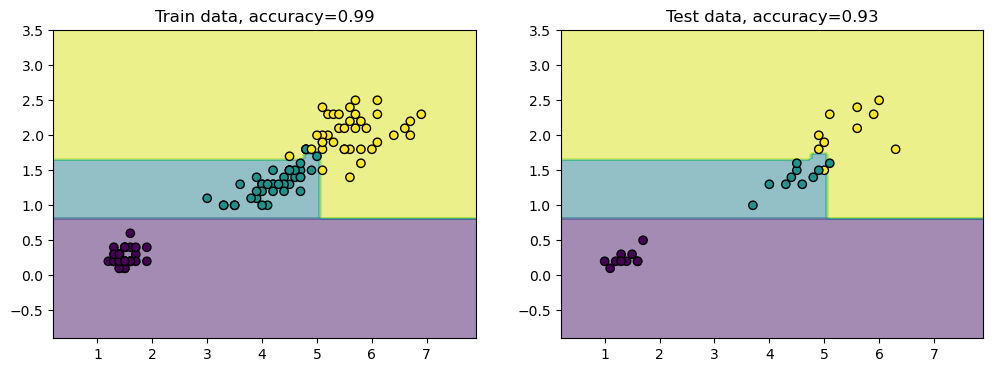

In [45]:
import numpy as np
import matplotlib.pyplot as plt

plot_decision_surface(model, X_train, X_test, Y_train, Y_test)

#### Демонстрация переобучения дерева решений

Продемонстрируем эффект переобучения метода решающих деревьев на синтетическом датасете.
Подгрузим необходимые библиотеки, сгенерируем датасет для задачи классификации по двум признакам с тремя классами. 

Для генерации данных можно использовать методы `sklearn.datasets.make_blobs()` или `sklearn.datasets.make_classification()`.

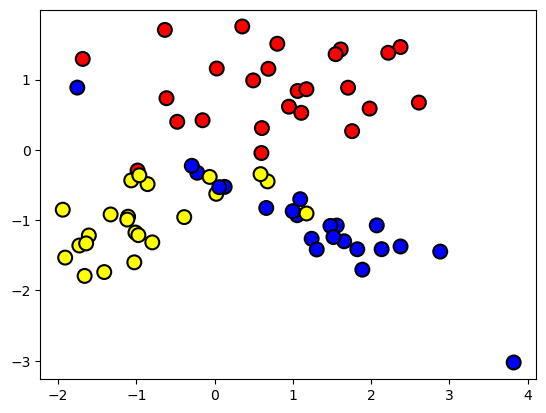

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn import datasets 
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# генерация данных
X, Y = datasets.make_blobs(n_samples=250, centers=[(0,1),(-3,-3),(4,2)], 
                                      n_features=2, random_state=137,
                                      cluster_std=(1.6,1.9,2,))

# генерация 3 классов
X, Y = datasets.make_classification(n_features = 2, n_informative = 2, 
                                                      n_classes = 3, n_redundant=0, 
                                                      n_clusters_per_class=1, random_state=3)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                    test_size = 0.3, 
                                                    random_state=137, 
                                                    stratify = Y)

colors = ListedColormap(['red', 'blue', 'yellow'])
light_colors = ListedColormap(['lightcoral', 'lightblue', 'lightyellow'])
# визуализация данных
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, s=100, 
            cmap=colors, edgecolors='black', linewidth=1.5);

In [84]:
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print("Точность предсказания (accuracy) равна  ", accuracy_score(Y_test,Y_pred)*100)

Точность предсказания (accuracy) равна   83.33333333333334


Продемонстрируем влияние параметра глубины дерева на модель решающего дерева. Обучим несколько моделей решающего дерева с различными параметрами максимальной глубины дерева. Для визуализации действия решающей функции на входных данных, напишем вспомогательные методы.

In [136]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_decision_surface(model, X_train, X_test, Y_train, Y_test):

    # обучение переданной модели
    model.fit(X_train, Y_train)

    plt.figure(figsize=(12, 4))
    ax = plt.subplot(1, 2, 1)
    # решающая функция на обучающей выборке
    disp = DecisionBoundaryDisplay.from_estimator(model, X_train, 
                                                  response_method="predict",
                                                  ax = ax,
                                                  alpha=0.5)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, edgecolor="k")
    plt.title('Train data, accuracy={:.2f}'.format(accuracy_score(Y_train, model.predict(X_train))))
    
    # решающая функция на тестовой выборке
    ax = plt.subplot(1, 2, 2)
    # решающая функция на обучающей выборке
    disp = DecisionBoundaryDisplay.from_estimator(model, X_train, 
                                                  response_method="predict",
                                                  ax = ax,
                                                  alpha=0.5)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolor="k")
    plt.title('Test data, accuracy={:.2f}'.format(accuracy_score(Y_test, model.predict(X_test))))

График решающей функции дерева с максимальной глубиной 1.

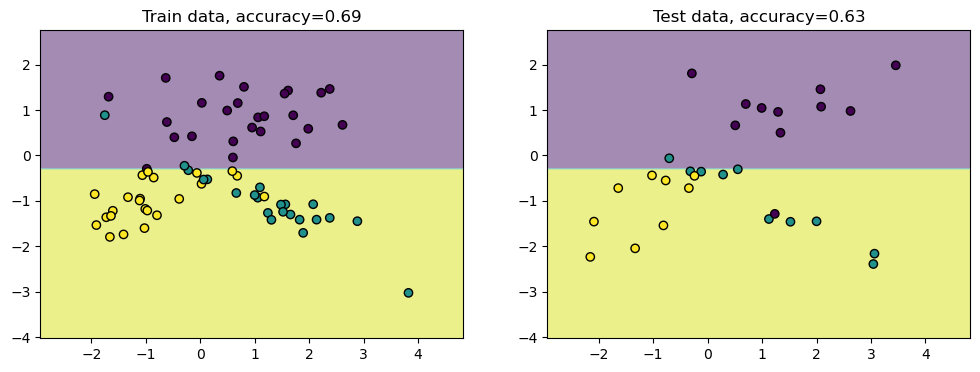

In [137]:
model = DecisionTreeClassifier(criterion='entropy', random_state = 1, max_depth = 1)

plot_decision_surface(model, X_train, X_test, Y_train, Y_test)

График решающей функции дерева с максимальной глубиной 2.

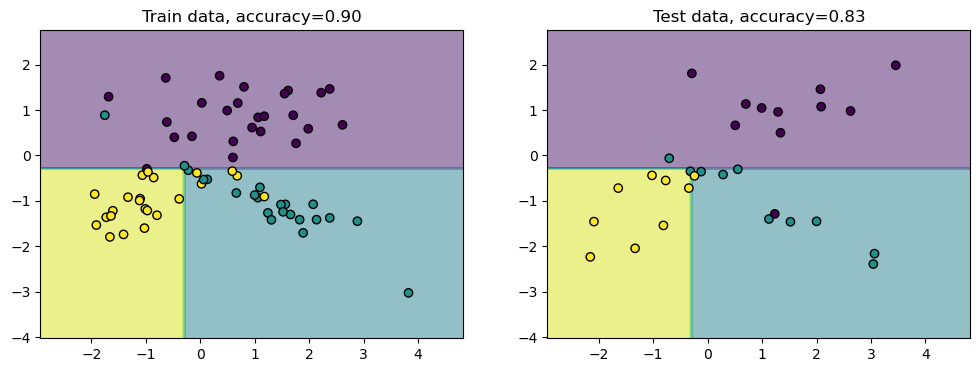

In [138]:
model = DecisionTreeClassifier(criterion='entropy', random_state = 1, max_depth = 2)

plot_decision_surface(model, X_train, X_test, Y_train, Y_test)

График решающей функции дерева с максимальной глубиной 3.

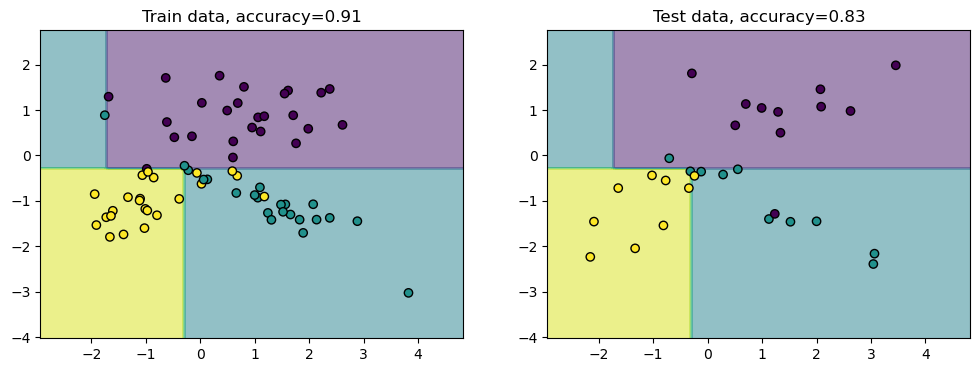

In [139]:
model = DecisionTreeClassifier(criterion='entropy', random_state = 1, max_depth = 3)

plot_decision_surface(model, X_train, X_test, Y_train, Y_test)

График решающей функции дерева без ограничения по глубине.

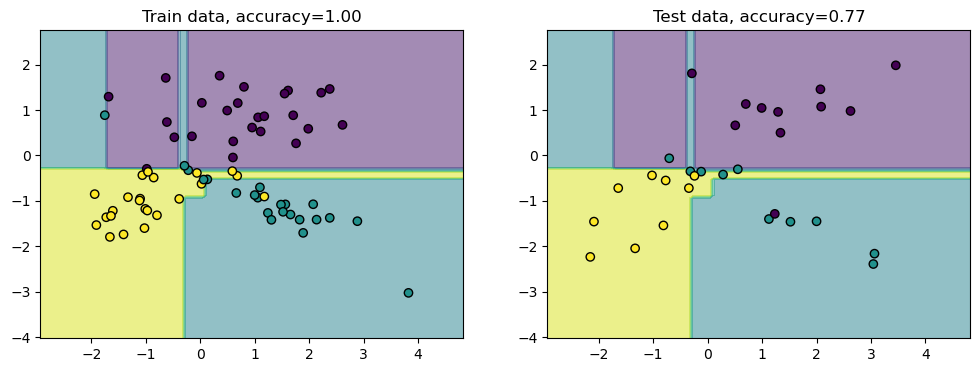

In [140]:
model = DecisionTreeClassifier(criterion='entropy', random_state = 1)

plot_decision_surface(model, X_train, X_test, Y_train, Y_test)

Иллюстрации показывают, что решающие деревья могут очень неплохо отделять каждый класс от всех остальных. Также видно, что решающая функция кусочно-постоянна и при этом каждый участок постоянства имеет границы параллельные осям координат, так как каждое условие сравнивает значение одного из признаков с порогом.

Крмое того, видно, что если не ставить ограничения на параметры дерева (такие как, например, глубина, число элементов в листьях), что решающее дерево легко может переобучиться. Действительно, при неограниченной глубине дерево можно сделать настолько глубоким, что каждый лист решающего дерева будет соответствовать ровно одному объекту обучающей выборки. В этом случае, если записать в каждом листе ответ соответствующего объекта, на обучающей выборке получается нулевая ошибка. Однако, качество на тестовой выборке будет гораздо хуже, то есть дерево получается явно переобученным.

Ограничим для примера минимальное число объектов в листьях.

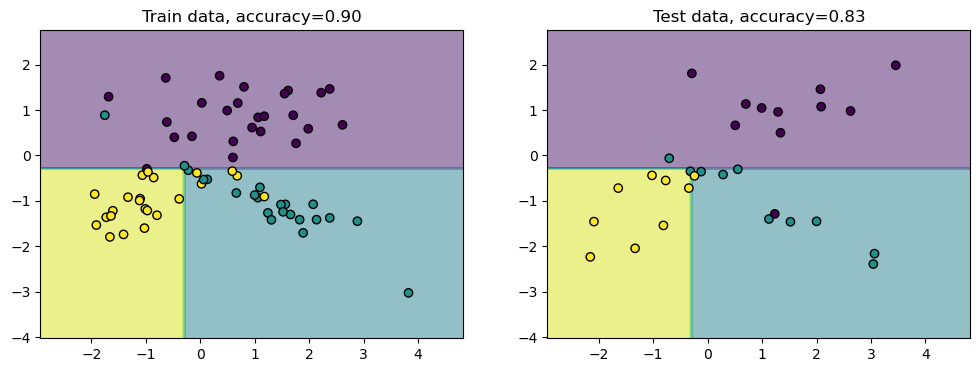

In [141]:
model = DecisionTreeClassifier(criterion='entropy', random_state = 1, min_samples_leaf = 8)

plot_decision_surface(model, X_train, X_test, Y_train, Y_test)